In [1]:
import re, os, numpy as np, pandas as pd
from pathlib import Path
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt

"""
conda env create -f environment.yml
conda activate code_status_env
python -m ipykernel install --user --name code_status_env --display-name "Python (code_status_env)"
"""

# --- configure paths
working_dir = Path("/Users/reblocke/Research/code-status-exploration")
database_loc = Path("Data/Resident Attitudes and Behaviors Surrounding Code-Status Discussions - Final_November 3, 2025_09.43.xlsx")
xlsx_path = working_dir / database_loc

# --- read with the 2nd row as headers (Qualtrics "question text"), keep strings
df = pd.read_excel(xlsx_path, header=1, dtype="object")

# --- drop the first data row if it contains the JSON ImportId markers
if df.iloc[0].astype(str).str.contains("ImportId").any():
    df = df.iloc[1:].reset_index(drop=True)

# --- normalize weird encodings sometimes seen in Qualtrics exports
def fix_mojibake(s):
    if not isinstance(s, str):
        return s
    rep = {"‚Äô": "’", "‚Äú": "“", "‚Äù": "”", "â€“": "–", "â€”": "—", "Â": ""}
    for k, v in rep.items():
        s = s.replace(k, v)
    return re.sub(r"\s+", " ", s).strip()

df.columns = [fix_mojibake(str(c)) for c in df.columns]

In [2]:
# Locate the PGY column by QID or label
pgy_candidates = [c for c in df.columns if ("[QID29]" in c) or ("i am a" in c.lower())]
assert len(pgy_candidates) >= 1, "Couldn't find PGY column (expected QID29)."
pgy_col = pgy_candidates[0]

def normalize_pgy(x: str) -> str:
    if not isinstance(x, str):
        return "Other"
    s = x.strip().lower()
    # Collapse typical qualtrics answers:
    if ("pgy1" in s) or ("pgy 1" in s) or ("pgy-1" in s) or ("intern" in s) or ("categorical" in s) or ("med-peds" in s) or ("prelim" in s):
        return "PGY1"
    if ("pgy2" in s) or ("pgy 2" in s) or ("pgy-2" in s):
        return "PGY2"
    if ("pgy3/4" in s) or ("pgy3" in s) or ("pgy 3" in s) or ("pgy-3" in s) or ("pgy4" in s) or ("pgy 4" in s) or ("pgy-4" in s):
        return "PGY3/4"

df["PGY_cat"] = df[pgy_col].map(normalize_pgy).astype(
    CategoricalDtype(categories=["PGY1", "PGY2", "PGY3/4"], ordered=True)
)

# Analysis set: restrict to the three PGY groups if desired
analysis_df = df[df["PGY_cat"].isin(["PGY1", "PGY2", "PGY3/4"])].copy()

In [3]:
import re
from pandas.api.types import CategoricalDtype

LIKERT_TEMPLATES = {
    "FREQ5":  ["Never","Rarely","Sometimes","Often","Always"],
    "FREQ4":  ["Never","Rarely","Sometimes","Often"],
    "AGREE5": ["Strongly disagree","Disagree","Neutral","Agree","Strongly agree"],
    # Confidence variants: with and without "Extremely", and using "None" label
    "CONF5":  ["None","Slightly confident","Somewhat confident","Very confident","Extremely confident"],
    "CONF4":  ["None","Slightly confident","Somewhat confident","Very confident"],
}

# normalize tokens -> canonical label
LIKERT_CANON = {
    # frequency
    "never":"Never","rarely":"Rarely","sometimes":"Sometimes","often":"Often","always":"Always",
    # agreement
    "strongly disagree":"Strongly disagree","disagree":"Disagree","neither agree nor disagree":"Neutral",
    "neutral":"Neutral","agree":"Agree","strongly agree":"Strongly agree",
    # confidence (map all “no confidence” variants to "None")
    "none":"None","no confidence":"None","no-confidence":"None","not confident":"None",
    "not at all confident":"None","not-at-all confident":"None",
    "slightly confident":"Slightly confident","somewhat confident":"Somewhat confident",
    "very confident":"Very confident","extremely confident":"Extremely confident",
}

def coerce_likert(series: pd.Series):
    s = series.astype(str).str.strip()
    mapped = s.str.lower().map(LIKERT_CANON).fillna(s)  # keep original if unknown
    uniq = set(mapped.dropna().unique().tolist())

    # choose best template by overlap; on ties prefer the shorter template
    best_tpl, best_score = None, -1
    for _, order in LIKERT_TEMPLATES.items():
        score = len(uniq.intersection(set(order)))
        if score > best_score or (score == best_score and best_tpl is not None and len(order) < len(best_tpl)):
            best_tpl, best_score = order, score

    if best_score <= 1:
        return None

    # KEEP FULL TEMPLATE ORDER so all instrument levels remain visible downstream
    cats = list(best_tpl)
    coerced = mapped.astype(CategoricalDtype(categories=cats, ordered=True))
    return coerced, cats

# ----- detect ranks 1..4
def is_rank_1to4(series: pd.Series) -> bool:
    vals = pd.Series(series).dropna().astype(str).str.strip().unique()
    return len(vals) > 0 and set(vals).issubset({"1","2","3","4"})

def coerce_rank(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().astype(CategoricalDtype(categories=["1","2","3","4"], ordered=True))

# ----- multi-select + free-text logic
DELIMS = [";", "|", ","]
MULTISELECT_HINTS = [  # phrases that indicate check-all-that-apply
    "select all that apply", "select as many as you want", "check all that apply",
    "select as many as", "choose all that apply"
]
FREE_TEXT_HINTS = [  # phrases that indicate free text; also block Q16/Q17 explicitly
    "in your own words", "free-text", "free text", "_text"
]
FREE_TEXT_QIDS = {"q16", "q17"}  # dataset-specific: block these regardless of punctuation

def is_free_text_col(name: str, series: pd.Series) -> bool:
    n = str(name).lower()
    if any(h in n for h in FREE_TEXT_HINTS):
        return True
    if any(re.search(rf"\b{qid}\b", n) for qid in FREE_TEXT_QIDS):
        return True
    # heuristic: lots of unique, long responses => likely free text
    s = series.dropna().astype(str)
    if len(s) >= 8:
        uniq_ratio = s.nunique() / len(s)
        if uniq_ratio >= 0.7 and s.str.len().median() >= 12:
            return True
    return False

def header_says_multiselect(name: str) -> bool:
    n = str(name).lower()
    return any(h in n for h in MULTISELECT_HINTS)

def expand_multiselect(df_in: pd.DataFrame, col: str) -> list[str]:
    """Expand a *true* multi-select parent into one-hot option columns.
       Skips free-text; only acts if header indicates multi-select and delimiter is present."""
    if not header_says_multiselect(col):
        return []
    if is_free_text_col(col, df_in[col]):
        return []

    sample = df_in[col].astype(str).dropna()
    delim = next((d for d in DELIMS if sample.str.contains(re.escape(d)).any()), None)
    if delim is None:
        # Already exported one column per option → nothing to expand
        return []

    # collect options
    options = set()
    sample.str.split(delim).apply(lambda xs: options.update([x.strip() for x in xs if str(x).strip()]))
    options = sorted(o for o in options if o)

    new_cols = []
    for opt in options:
        new_name = f"{col} – {opt}"
        df_in[new_name] = df_in[col].astype(str).str.contains(rf"(^|{re.escape(delim)})\s*{re.escape(opt)}\s*(?:{re.escape(delim)}|$)",
                                                             case=False, na=False).astype(int)
        new_cols.append(new_name)
    return new_cols

# ----- Apply coercions across columns (skip free-text entirely)
ordinal_cols, rank_cols, multiselect_cols, multiselect_expanded = [], [], [], []

for c in analysis_df.columns:
    if c == "PGY_cat":
        continue
    s = analysis_df[c]

    # skip free-text early: no coercion, no multi-select expansion, not in TableOne
    if is_free_text_col(c, s):
        continue

    # Likert?
    lk = coerce_likert(s)
    if lk is not None:
        coerced, cats = lk
        analysis_df[c] = coerced
        ordinal_cols.append(c)
        continue

    # Rank 1..4?
    if is_rank_1to4(s):
        analysis_df[c] = coerce_rank(s)
        rank_cols.append(c)
        continue

    # Candidate multi-select by delimiter *and* header hint (prevents free-text misfires)
    if header_says_multiselect(c):
        vals = s.astype(str)
        if any(vals.str.contains(re.escape(d), na=False).any() for d in DELIMS):
            multiselect_cols.append(c)

# expand multi-selects (if any)
for mc in multiselect_cols:
    multiselect_expanded.extend(expand_multiselect(analysis_df, mc))

# All categorical to include in TableOne (free-text are excluded by design)
categorical_vars = sorted(set(ordinal_cols + rank_cols + multiselect_expanded))

/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/2765623899.py:106: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_in[new_name] = df_in[col].astype(str).str.contains(rf"(^|{re.escape(delim)})\s*{re.escape(opt)}\s*(?:{re.escape(delim)}|$)",
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/2765623899.py:106: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_in[new_name] = df_in[col].astype(str).str.contains(rf"(^|{re.escape(delim)})\s*{re.escape(opt)}\s*(?:{re.escape(delim)}|$)",
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/2765623899.py:106: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_in[new_name] = df_in[col].astype(str).str.contains(rf"(^|{re.escape(delim)})\s*{re.e

In [4]:
def audit_ordinal_counts(df: pd.DataFrame, cols: list[str], group_col: str = "PGY_cat") -> pd.DataFrame:
    rows = []
    for c in cols:
        s = df[c]
        before_n = df[c].notna().sum()
        after_n  = df[[c, group_col]].dropna().shape[0]  # N used in CMH (item + PGY non-missing)
        unk_vals = (df[c].astype(str)
                      .loc[df[c].isna()]  # now NaN after coercion
                      .value_counts()
                      .head(5)
                      .to_dict())
        cats = list(s.cat.categories) if pd.api.types.is_categorical_dtype(s) else []
        rows.append({
            "Item": c, "N_nonmissing_item": int(before_n), "N_used_CMH": int(after_n),
            "n_levels": len(cats), "levels": " | ".join(cats[:10]),
            "top_unmapped_tokens_became_NaN": str(unk_vals)
        })
    return pd.DataFrame(rows).sort_values(["N_nonmissing_item","Item"], ascending=[False, True])

audit_df = audit_ordinal_counts(analysis_df, list(ordinal_cols + rank_cols))
print(audit_df.to_string(index=False, max_colwidth=80))

                                                                            Item  N_nonmissing_item  N_used_CMH  n_levels                                                          levels top_unmapped_tokens_became_NaN
Aside from CPR and intubation, what other topics do you think are most import...                 37          37         4                                                   1 | 2 | 3 | 4                             {}
Aside from CPR and intubation, what other topics do you think are most import...                 37          37         4                                                   1 | 2 | 3 | 4                             {}
Aside from CPR and intubation, what other topics do you think are most import...                 37          37         4                                                   1 | 2 | 3 | 4                             {}
Aside from CPR and intubation, what other topics do you think are most import...                 37          37         4           

/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/3390352439.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  cats = list(s.cat.categories) if pd.api.types.is_categorical_dtype(s) else []
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/3390352439.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  cats = list(s.cat.categories) if pd.api.types.is_categorical_dtype(s) else []
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/3390352439.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  cats = list(s.cat.categories) if pd.api.types.is_categorical_dtype(s) else []
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/33903

In [5]:
# pip install tableone  # if needed
try:
    from tableone import TableOne

    # Drop free-text columns if present
    drop_text = [c for c in analysis_df.columns if c.endswith("_TEXT]") or c.lower().endswith("_text")]
    tdf = analysis_df.drop(columns=drop_text, errors="ignore")

    table1 = TableOne(
        data=tdf,
        columns=categorical_vars,
        groupby="PGY_cat",
        categorical=categorical_vars,
        pval=True,  # chi-square across PGY groups
        overall=True,
        missing=False
    )
    print(table1.tabulate(tablefmt="github"))
    # Save to Excel
    fn1 = 'tableone.xlsx'
    table1.to_excel(fn1)
except Exception as e:
    print(f"TableOne unavailable ({e}); building a simple categorical summary.")
    glevels = ["PGY1","PGY2","PGY3/4"]
    out = []
    for col in categorical_vars:
        ct = pd.crosstab(tdf[col], tdf["PGY_cat"])[glevels].reindex(glevels, axis=1, fill_value=0)
        ct_pct = ct.div(ct.sum(axis=0), axis=1).mul(100).round(1)
        out.append(pd.concat({"n": ct, "%": ct_pct}, axis=1))
    table1_fallback = pd.concat(out, keys=categorical_vars)
    table1_fallback

|                                                                                                                                                                                                                                                                                                                                                                            |                    | Overall   | PGY1       | PGY2       | PGY3/4    | P-Value   |
|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------|-----------|------------|------------|-----------|-----------|
| n                                                                                                 

/opt/anaconda3/envs/code_status_env/lib/python3.11/site-packages/tableone/preprocessors.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupbylvls = sorted(data.groupby(groupby).groups.keys())  # type: ignore
/opt/anaconda3/envs/code_status_env/lib/python3.11/site-packages/tableone/formatting.py:184: UserWarning: Order value not found: "For ED admits to the ICU, how often do you conduct a code-status exploration rather than only verification of previously decided goals of care? - 1.: ['Never']"
  warnings.warn(f'Order value not found: "{k}: {rm_var}"')
/opt/anaconda3/envs/code_status_env/lib/python3.11/site-packages/tableone/formatting.py:184: UserWarning: Order value not found: "How often do you think code-status explorations should be part of patients’ ICU admissions rather than verificati

## Heatmaps for all the questions

In [6]:
# ===================== Heatmaps (flipped y for Likert; robust coverage) =====================
import os, re, textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from collections import defaultdict

# ---- sizing knobs (adjust these, nothing else) ----
ROW_HEIGHT   = 0.36   # inches per heatmap row
BASE_HEIGHT  = 1.8    # inches of fixed overhead (axes, title, cbar)
BASE_WIDTH   = 6.6    # default width close to your original
MAX_WIDTH    = 9.2    # hard cap to avoid very wide figures
W_PER_100CH  = 0.35   # extra inches per 100 chars of title (keeps long titles from clipping)
WRAP_CHARS   = 70     # title wrap width (fewer = more wrap, narrower figure)

PLOT_DIR = Path("plots")
PLOT_DIR.mkdir(exist_ok=True)
PGY_LEVELS = ["PGY1","PGY2","PGY3/4"]

def percent_matrix(series: pd.Series, group: pd.Series, row_order: list[str] | None = None):
    # robust: keep PGY order and fill absent columns with 0
    ct = pd.crosstab(series, group, dropna=False).reindex(columns=PGY_LEVELS, fill_value=0)
    if row_order is not None:
        ct = ct.reindex(row_order, fill_value=0)
    pct = ct.div(ct.sum(axis=0).replace(0, np.nan), axis=1).mul(100)
    return pct.fillna(0), ct.fillna(0)

def _wrap_title(title: str, width: int = WRAP_CHARS) -> str:
    title = re.sub(r"\s+", " ", str(title)).strip()
    return textwrap.fill(title, width=width)

def plot_heatmap(mat: pd.DataFrame, counts: pd.DataFrame, title: str, fname: Path):
    # height scales with rows; width increases mildly with title length
    nrows   = max(1, mat.shape[0])
    height  = BASE_HEIGHT + ROW_HEIGHT * nrows
    width   = min(MAX_WIDTH, BASE_WIDTH + W_PER_100CH * (len(str(title)) / 100.0))

    fig, ax = plt.subplots(figsize=(width, height))
    im = ax.imshow(mat.values, aspect="auto")

    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
    ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
    ax.set_title(_wrap_title(title, WRAP_CHARS), pad=6)

    # annotate % and n with smaller text so the plot area can stay compact
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat.iloc[i, j]:.0f}%\n(n={int(counts.iloc[i, j])})",
                    ha="center", va="center", fontsize=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.set_ylabel("% within PGY", rotation=270, labelpad=10, fontsize=9)

    fig.tight_layout(pad=0.6)
    fig.savefig(fname, bbox_inches="tight", dpi=300)
    plt.close(fig)

# ---------- helpers to decide flip ----------
_NUMERIC_RE = re.compile(r"^\d+(\.\d+)?$")

def _is_numeric_order(order: list) -> bool:
    if order is None: 
        return False
    return all(_NUMERIC_RE.match(str(x).strip() or "") for x in order)

def _row_order_for_plot(series: pd.Series) -> list[str] | None:
    """Return the plotting row order. 
       - If ordered categorical:
           * flip for non-numeric Likert-like labels (Always at top, Never at bottom)
           * keep numeric ranks ascending (1 at top)
       - If not ordered, return None."""
    if isinstance(series.dtype, CategoricalDtype) and series.dtype.ordered:
        cats = list(series.cat.categories)
        # flip only when categories are not purely numeric (Likert-style)
        if not _is_numeric_order(cats):
            return list(reversed(cats))   # e.g., Always→top, Never→bottom
        else:
            return cats                   # e.g., 1→top ... 4→bottom
    return None

# ---------- build robust lists of items to plot ----------
# Start with your prepared lists if present; else infer from dtypes
prepared_ord = list(ordinal_cols) if 'ordinal_cols' in globals() else []
prepared_rank = list(rank_cols) if 'rank_cols' in globals() else []

auto_ordered = [
    c for c in analysis_df.columns
    if c not in ("PGY_cat",)
    and pd.api.types.is_categorical_dtype(analysis_df[c])
    and isinstance(analysis_df[c].dtype, CategoricalDtype)
    and analysis_df[c].dtype.ordered
]

# union ensures we don't miss items if earlier coercion lists were incomplete
likert_rank_cols = sorted(set(prepared_ord + prepared_rank + auto_ordered))

# Multi-select groups:
# Prefer your expanded list if present; otherwise detect one-hot groups by the " – " stem and 0/1 values.
if 'multiselect_expanded' in globals() and len(multiselect_expanded) > 0:
    ms_cols_all = list(multiselect_expanded)
else:
    ms_cols_all = []
    for c in analysis_df.columns:
        if " – " in str(c) and analysis_df[c].dropna().isin([0, 1, "0", "1"]).all():
            ms_cols_all.append(c)

ms_groups = defaultdict(list)
for c in ms_cols_all:
    parent = c.split(" – ")[0]
    ms_groups[parent].append(c)
# keep only parents with ≥2 options
ms_groups = {p: sorted(cols) for p, cols in ms_groups.items() if len(cols) >= 2}

# ---------- generate heatmaps ----------
plotted, skipped = [], {}

# Likert + Rank (with flipped y for Likert-like)
for col in likert_rank_cols:
    s = analysis_df[col]
    # compute desired plotting order
    row_order_plot = _row_order_for_plot(s)
    if row_order_plot is None:
        skipped[col] = "not ordered categorical"
        continue
    pm, ct = percent_matrix(s, analysis_df["PGY_cat"], row_order=row_order_plot)
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", col)[:120]
    out_path = PLOT_DIR / f"heatmap_{safe_name}.png"
    plot_heatmap(pm, ct, title=col, fname=out_path)
    plotted.append(col)

# Multi‑select (rows = options; no flip here)
for parent, cols in ms_groups.items():
    opt_mat, opt_counts, row_labels = [], [], []
    for c in cols:
        pm, ct = percent_matrix(
            analysis_df[c].map({1: "Selected", 0: "Not selected"}),
            analysis_df["PGY_cat"],
            row_order=["Selected"]
        )
        opt_mat.append(pm.loc["Selected"])
        opt_counts.append(ct.loc["Selected"])
        row_labels.append(c.replace(parent + " – ", ""))

    if not opt_mat:
        skipped[parent] = "no selectable options"
        continue

    mat = pd.DataFrame(opt_mat, index=row_labels, columns=PGY_LEVELS)
    cnt = pd.DataFrame(opt_counts, index=row_labels, columns=PGY_LEVELS)

    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", parent)[:120]
    out_path = PLOT_DIR / f"heatmap_{safe_name}.png"
    plot_heatmap(mat, cnt, title=f"{parent} (Selected %)", fname=out_path)
    plotted.append(parent + " (multi-select)")

print(f"Saved heatmaps → {PLOT_DIR.resolve()}")
print(f"Plotted {len(plotted)} heatmaps; Skipped {len(skipped)}.")
if skipped:
    # brief reasons so you know why some did not plot
    for k, v in list(skipped.items())[:12]:  # print a few
        print(f"  - Skipped: {k} → {v}")
    if len(skipped) > 12:
        print(f"  … and {len(skipped)-12} more")

/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/601831486.py:91: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  and pd.api.types.is_categorical_dtype(analysis_df[c])
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/601831486.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=0.6)


Saved heatmaps → /Users/reblocke/Research/code-status-exploration/plots
Plotted 17 heatmaps; Skipped 0.


### Cochrane-Mantel-Hansel test

Evaluate for associations by PGY-year

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
from pandas.api.types import CategoricalDtype

def cmh_linear_by_linear(series: pd.Series,
                         group: pd.Series,
                         row_scores=None,
                         col_scores=None,
                         col_order=("PGY1","PGY2","PGY3/4")) -> float | None:
    """
    Linear-by-linear association (CMH) for an ordered-by-ordered R×C table.
    Returns a two-sided p-value (chi^2, df=1). Returns None if not computable.
    """
    if not (isinstance(series.dtype, CategoricalDtype) and series.dtype.ordered):
        return None

    # build table in requested PGY order; fill missing cols with 0
    tab = (pd.crosstab(series, group, dropna=False)
             .reindex(index=list(series.cat.categories), columns=list(col_order), fill_value=0)
             .values)

    # drop all-zero rows/cols
    row_mask = tab.sum(axis=1) > 0
    col_mask = tab.sum(axis=0) > 0
    tab = tab[row_mask][:, col_mask]

    n = tab.sum()
    if n == 0 or tab.shape[0] < 2 or tab.shape[1] < 2:
        return None

    K, J = tab.shape
    a = np.arange(1, K+1, dtype=float) if row_scores is None else np.asarray(row_scores, dtype=float)[:K].astype(float)
    b = np.arange(1, J+1, dtype=float) if col_scores is None else np.asarray(col_scores, dtype=float)[:J].astype(float)

    r_tot = tab.sum(axis=1)
    c_tot = tab.sum(axis=0)
    a_bar = (a * r_tot).sum() / n
    b_bar = (b * c_tot).sum() / n

    # numerator = covariance * n  ; denominators are variance * n
    num  = (((a[:, None] - a_bar) * (b[None, :] - b_bar)) * tab).sum()
    s_r2 = (((a - a_bar)**2) * r_tot).sum()
    s_c2 = (((b - b_bar)**2) * c_tot).sum()
    if s_r2 <= 0 or s_c2 <= 0:
        return None

    stat = (n * (num**2)) / (s_r2 * s_c2)   # correct n factor
    return float(1 - chi2.cdf(stat, df=1))

# Example:
cmh_results = {
    col: cmh_linear_by_linear(analysis_df[col], analysis_df["PGY_cat"])
    for col in (ordinal_cols + rank_cols)
}

In [8]:
# === Pretty CMH results table (drop-in replacement for the last statement) ===
from statsmodels.stats.multitest import multipletests
from IPython.display import display

rows = []
items = list(ordinal_cols + rank_cols)

for col in items:
    p = cmh_linear_by_linear(analysis_df[col], analysis_df["PGY_cat"])
    # N for this test = complete cases on item + PGY
    n = analysis_df[[col, "PGY_cat"]].dropna().shape[0]
    # how many ordered levels used (after dropping empties inside the test)
    try:
        k = len([lv for lv in analysis_df[col].cat.categories
                 if (analysis_df[col] == lv).sum() > 0])
    except Exception:
        k = analysis_df[col].nunique(dropna=True)
    rows.append({"Item": col, "N": n, "Levels": k, "p": p})

cmh_df = pd.DataFrame(rows)

# BH-FDR adjustment
mask = cmh_df["p"].notna()
if mask.any():
    cmh_df.loc[mask, "q_BH"] = multipletests(cmh_df.loc[mask, "p"], method="fdr_bh")[1]

# nice formatting
cmh_df["p_fmt"] = cmh_df["p"].apply(lambda x: f"{x:.3g}" if pd.notna(x) else "NA")
cmh_df["q_fmt"] = cmh_df["q_BH"].apply(lambda x: f"{x:.3g}" if pd.notna(x) else "NA")

# order and sort by p
cmh_pretty = (cmh_df
              .loc[:, ["Item", "N", "Levels", "p_fmt", "q_fmt"]]
              .rename(columns={"p_fmt": "p", "q_fmt": "q (BH-FDR)"}))

# display nicely in notebooks and save a CSV
display(cmh_pretty.style.format({"N": "{:.0f}", "Levels": "{:.0f}"}))
cmh_pretty.to_csv("cmh_results_by_item.csv", index=False)
print("Wrote Outputs/cmh_results_by_item.csv")

,Item,N,Levels,p,q (BH-FDR)
0,"For ED admits to the ICU, how often do you conduct a code-status exploration rather than only verification of previously decided goals of care? - 1.",37,4,0.0714,0.268
1,"For transfers to the ICU coming from another hospital, how often do you conduct a code-status exploration rather than only verification of previously decided goals of care? - 2.",37,5,0.0186,0.139
2,"For floor transfers to the ICU, how often do you conduct a code-status exploration rather than only verification of previously decided goals of care? - 3.",37,5,0.446,0.608
3,How often do you think code-status explorations should be part of patients’ ICU admissions rather than verification of previously documented/expressed code-status? - 4.,37,3,0.286,0.536
4,How often do time constraints prevent you from spending as much time on code-status explorations as you feel you should during ICU admissions? - 5.,37,4,0.413,0.608
5,How confident do you feel conducting code status explorations on initial ICU admission with your current level of training? - 6.,26,4,0.00129,0.0194
6,How often do you perceive that patients or their surrogates don't adequately understand the questions asked or clinical circumstances well enough to make informed choices during code-status explorations on ICU admission? - 8.,37,4,0.624,0.72
7,How often do you conduct code-status explorations with patients on ICU admission for whom you do not feel it is clinically indicated because you feel it is expected/required of you? - 9.,37,4,0.166,0.414
8,"For ED admits to the ICU, how often do you document a “temporary” or “provisional” code-status with a plan to revisit the discussion later? - 10.",37,4,0.934,0.934
9,I think more training on when to conduct a code status exploration vs verification on ICU admission would lead to improvements in ICU care. - 11.,37,4,0.158,0.414


Wrote Outputs/cmh_results_by_item.csv


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.patches as mpatches
import textwrap
from typing import Sequence, Mapping, Optional, Iterable, Dict, List, Tuple

def plot_single_answer_stacks(
    df: pd.DataFrame,
    question_cols: Optional[Sequence[str]] = None,
    *,
    category_order: Optional[Sequence[str]] = None,
    per_question_category_orders: Optional[Mapping[str, Sequence[str]]] = None,
    question_labels: Optional[Mapping[str, str]] = None,
    exclude_values: Optional[Iterable[str]] = None,
    wrap: int = 60,
    # New/changed behavior
    color_by_rank: bool = True,                 # same color for the same ordinal rank across questions
    bar_label: str = "both",                    # "percent" | "label" | "both" | "none"
    min_text_width_pct: float = 7.0,            # annotate inside the segment only if width >= this percent
    per_question_legend: bool = False,          # put a legend to the right of each bar
    legend_fontsize: int = 8,
    bar_label_fontsize: int = 8,
    title: Optional[str] = None,
    figsize: Optional[Tuple[float, float]] = None,
    savepath: Optional[str] = None,
):
    """
    Key figure: horizontally-stacked bars for single-answer items.

    - Colors are assigned by ordinal rank (1, 2, 3, ...) if color_by_rank=True.
    - In-bar labels (percent + category) when segments are wide enough.
    - Optional per-question legend to the right (only categories present in that question).

    Parameters are the same as the previous version, with the new options listed above.
    """
    # ---- helpers ----
    def _is_cat(ser: pd.Series) -> bool:
        return pd.api.types.is_categorical_dtype(ser)

    def _resolve_order(col: str) -> List[str]:
        if per_question_category_orders and (col in per_question_category_orders):
            return [c for c in per_question_category_orders[col] if c not in exclude_values]
        if category_order is not None:
            return [c for c in category_order if c not in exclude_values]
        ser = df[col]
        if _is_cat(ser) and getattr(ser.dtype, "ordered", False):
            return [c for c in ser.cat.categories if c not in exclude_values]
        counts = ser.value_counts(dropna=True)
        ordered = [c for c in counts.index if c not in exclude_values]
        unseen = sorted(set(ser.dropna().unique()) - set(ordered))
        return ordered + unseen

    def _wrap_label(s: str) -> str:
        return textwrap.fill(str(s), width=wrap)

    def _text_color_for_rgb(rgb) -> str:
        # Perceptual luminance for contrast-aware text (white on dark, black on light)
        r, g, b = rgb[:3]
        def _lin(c):
            return c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4
        L = 0.2126*_lin(r) + 0.7152*_lin(g) + 0.0722*_lin(b)
        return "black" if L > 0.5 else "white"

    # ---- infer questions if not given ----
    if question_cols is None:
        qc = []
        for c in df.columns:
            ser = df[c]
            if _is_cat(ser) and getattr(ser.dtype, "ordered", False) and ser.dropna().nunique() >= 2:
                qc.append(c)
        if not qc:
            raise ValueError("Could not infer single-answer columns. Pass question_cols explicitly.")
        question_cols = qc

    question_cols = [c for c in question_cols if c in df.columns]
    if not question_cols:
        raise ValueError("None of the requested question columns are present in df.")

    exclude_values = set(exclude_values) if exclude_values is not None else set()
    per_q_orders: Dict[str, List[str]] = {col: _resolve_order(col) for col in question_cols}
    n_q = len(question_cols)

    # ---- rank-based color palette ----
    # Max number of response levels across all included questions
    max_ranks = max(len(per_q_orders[col]) for col in question_cols)
    # Use a perceptually uniform, color-blind-friendly colormap; sample mid-range for contrast
    cmap = plt.cm.get_cmap("viridis")
    palette = [cmap(x) for x in np.linspace(0.12, 0.88, max_ranks)]
    rank_color = {rank: palette[rank-1] for rank in range(1, max_ranks+1)}

    # ---- figure/axes ----
    if figsize is None:
        # Wider if we plan to show per-question legends on the right
        base_w = 9.0 if per_question_legend else 8.5
        figsize = (base_w, max(2.5, 0.55 * n_q + 1.5))
    fig, axes = plt.subplots(n_q, 1, figsize=figsize, sharex=True)
    if n_q == 1:
        axes = [axes]

    # ---- draw each question ----
    for ax, col in zip(axes, question_cols):
        ser = df[col].dropna()
        if exclude_values:
            ser = ser[~ser.isin(exclude_values)]

        order = [c for c in per_q_orders[col] if c in ser.unique()]
        counts = ser.value_counts().reindex(order).fillna(0)
        total = counts.sum()

        if total == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_yticks([])
            ax.set_xticks([])
            continue

        pct = (counts / total) * 100.0

        left = 0.0
        y = 0.0
        # bar segments
        for j, level in enumerate(order, start=1):
            w = float(pct.loc[level])
            if w <= 0:
                continue
            color = rank_color[j if color_by_rank else (j % max_ranks)]
            bar = ax.barh(
                y, w, left=left, height=0.8,
                color=color, edgecolor="white", linewidth=0.5
            )

            # in-bar text if wide enough
            if bar_label != "none" and w >= min_text_width_pct:
                if bar_label == "percent":
                    txt = f"{w:.0f}%"
                elif bar_label == "label":
                    txt = str(level)
                else:  # "both"
                    txt = f"{level} • {w:.0f}%"
                ax.text(
                    left + w / 2.0, y, txt,
                    ha="center", va="center",
                    fontsize=bar_label_fontsize,
                    color=_text_color_for_rgb(color),
                )

            left += w

        # Y label = question text
        label = question_labels.get(col, col) if question_labels else col
        ax.set_yticks([y])
        ax.set_yticklabels([_wrap_label(label)])
        ax.set_ylim(-0.6, 0.6)

        # Clean look
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)
        ax.tick_params(axis="y", length=0)

        # Optional per-question legend with only present categories (to the right)
        if per_question_legend:
            handles = [mpatches.Patch(facecolor=rank_color[i+1], label=str(level)) for i, level in enumerate(order)]
            ax.legend(
                handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5),
                frameon=False, fontsize=legend_fontsize, title=None, borderaxespad=0.0,
            )

    # Shared x axis in percent
    axes[-1].set_xlim(0, 100)
    for ax in axes:
        ax.xaxis.set_major_formatter(PercentFormatter(100))
        ax.set_xlabel("Percent of respondents")

    # Title
    if title:
        fig.suptitle(title, y=0.98)

    # Layout: reserve right margin if legends are drawn there
    if per_question_legend:
        fig.tight_layout(rect=(0.0, 0.0, 0.82, 0.97))
    else:
        fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))

    if savepath:
        import os
        os.makedirs(os.path.dirname(savepath) or ".", exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, axes

/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/1146394618.py:40: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return pd.api.types.is_categorical_dtype(ser)
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/1146394618.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis")


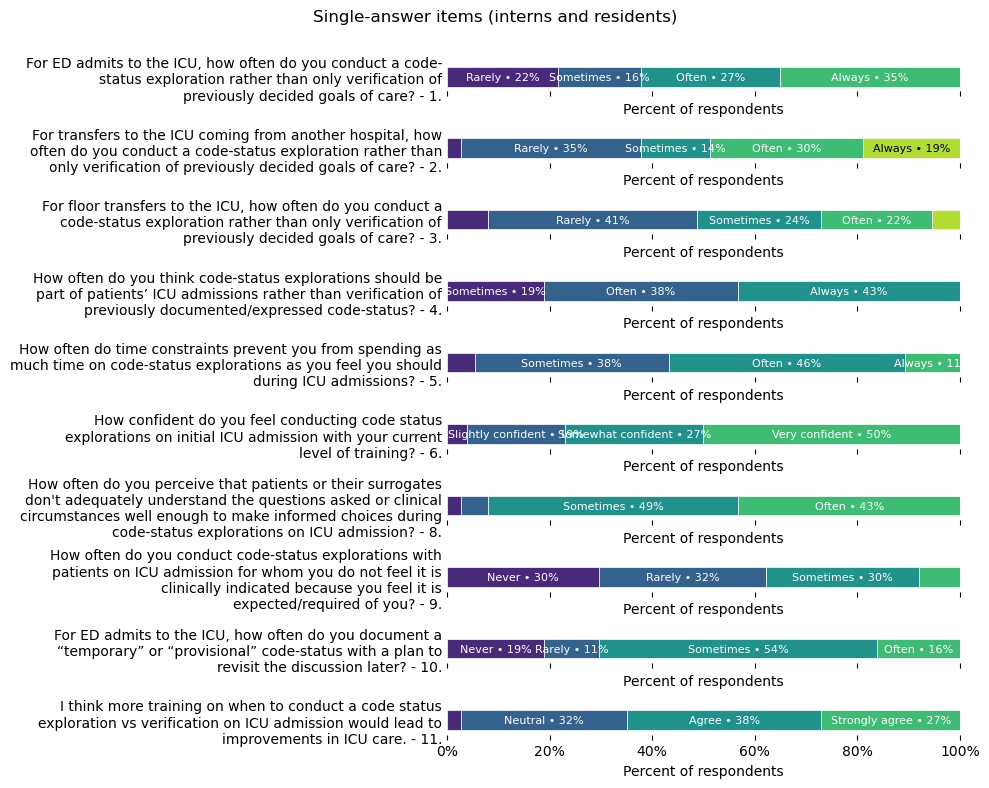

In [18]:
# If you already have these from earlier cells:
# analysis_df: respondent-level DataFrame
# ordinal_cols: list of single-answer question columns
# item_label_map: optional dict {column -> short label}

from pathlib import Path
Path("Outputs").mkdir(parents=True, exist_ok=True)

fig, axes = plot_single_answer_stacks(
    analysis_df,
    question_cols=ordinal_cols,
    question_labels=globals().get("item_label_map"),
    color_by_rank=True,          # <- consistent color by ordinal rank
    bar_label="both",            # "percent" | "label" | "both" | "none"
    min_text_width_pct=9.0,      # raise to reduce crowding
    per_question_legend=False,   # rely on in-bar labels
    title="Single‑answer items (interns and residents)",
    figsize=(10.0, 8.0),           # ← roughly 25–33 % wider than default 8.5
    savepath="Outputs/key_figure_single_answer.png",
)

/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/1146394618.py:40: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return pd.api.types.is_categorical_dtype(ser)
/var/folders/kc/jkd3yt1s0436pgb396mzmmn00000gn/T/ipykernel_32626/1146394618.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis")


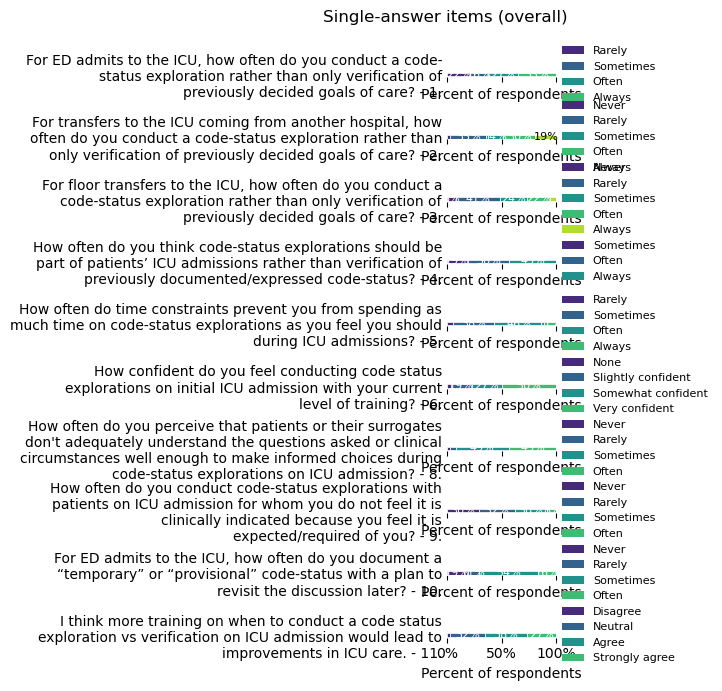

In [11]:
fig, axes = plot_single_answer_stacks(
    analysis_df,
    question_cols=ordinal_cols,
    question_labels=globals().get("item_label_map"),
    color_by_rank=True,
    bar_label="percent",         # lighter in-bar annotation
    per_question_legend=True,    # legend with only the levels present in that item
    title="Single‑answer items (overall)",
    savepath="Outputs/key_figure_single_answer_with_legends.png",
)